In [ ]:
# IMPORTANT: SOME KAGGLE DATA SOURCES ARE PRIVATE
# RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES.
import kagglehub
kagglehub.login()


In [ ]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.

shreeyamaskey01_plant_diseases_classification_data_path = kagglehub.dataset_download('shreeyamaskey01/plant-diseases-classification-data')
shreeyamaskey01_plant_diseases_classification_dataset_path = kagglehub.dataset_download('shreeyamaskey01/plant-diseases-classification-dataset')

print('Data source import complete.')


# **Part-2 Vision Task**

**1. Imports**

In [ ]:
import os
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import classification_report, confusion_matrix

**2. Check GPU**

In [ ]:
print("GPU Available:", tf.config.list_physical_devices('GPU'))

GPU Available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]


**3. Dataset Paths**

In [ ]:
import os
DATASET_ROOT = "/kaggle/input/datasets/shreeyamaskey01/plant-diseases-classification-dataset"

train_dir = os.path.join(DATASET_ROOT,"train","train")

val_dir = os.path.join(DATASET_ROOT,"val","val")

test_dir = os.path.join(DATASET_ROOT,"test","test")

**4. Smaller Image Size + Lower Batch**

In [ ]:
IMG_SIZE = (128, 128)
BATCH_SIZE = 8

**5. Load Dataset**

In [ ]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    val_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    test_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

class_names = train_ds.class_names
num_classes = len(class_names)

**6. Dataset Optimization**

In [ ]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.shuffle(500).prefetch(buffer_size=AUTOTUNE)

val_ds = val_ds.prefetch(buffer_size=AUTOTUNE)

test_ds = test_ds.prefetch(buffer_size=AUTOTUNE)

**8. Display Sample Images**

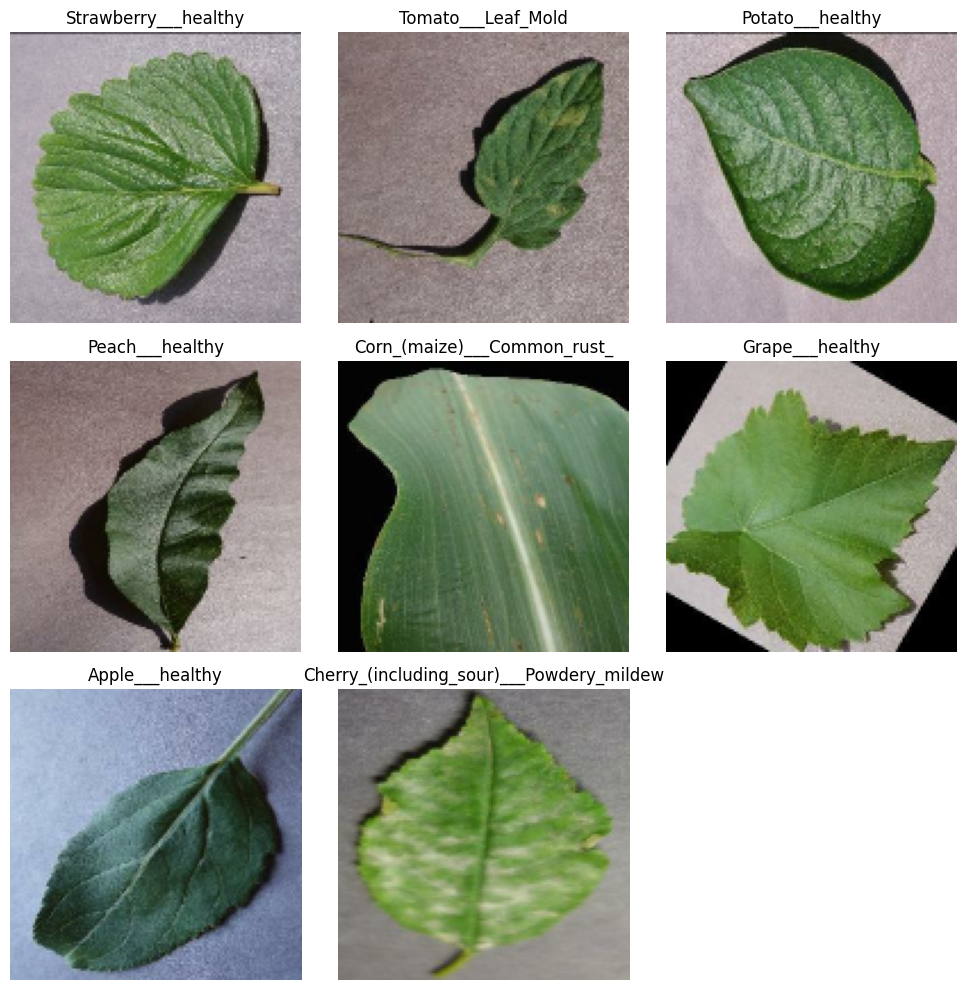

In [ ]:
plt.figure(figsize=(10,10))

for images, labels in train_ds.take(1):

    batch_size_actual = len(images)

    for i in range(min(9, batch_size_actual)):

        ax = plt.subplot(3,3,i+1)

        plt.imshow(images[i].numpy().astype("uint8"))

        plt.title(class_names[labels[i]])

        plt.axis("off")

plt.tight_layout()
plt.show()

**PART A — BASELINE CNN**

**9. Build Baseline CNN Model**

In [ ]:
baseline_model = models.Sequential([

    layers.Rescaling(1./255, input_shape=(150,150,3)),

    layers.Conv2D(16, (3,3), activation='relu'),
    layers.MaxPooling2D(),

    layers.Conv2D(32, (3,3), activation='relu'),
    layers.MaxPooling2D(),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(),

    layers.GlobalAveragePooling2D(),

    layers.Dense(128, activation='relu'),

    layers.Dense(num_classes, activation='softmax')

])

baseline_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/preprocessing/tf_data_layer.py:19: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 150, 150, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 148, 148, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 74, 74, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 72, 72, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 36, 36, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 34, 34, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 17, 17, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 64)             │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 38)             │         4,902 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 36,806 (143.77 KB)

 Trainable params: 36,806 (143.77 KB)

 Non-trainable params: 0 (0.00 B)

**10. Compile Baseline CNN**

In [ ]:
baseline_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

**11. Early Stopping**

In [ ]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

**12. Train Baseline CNN**

In [ ]:
start_time = time.time()

history_baseline = baseline_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    callbacks=[early_stop]
)

baseline_training_time = time.time() - start_time

print("Baseline Training Time:", baseline_training_time)

Epoch 1/10


I0000 00:00:1778344386.526280    3033 service.cc:152] XLA service 0x7c694c009640 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1778344386.526318    3033 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1778344386.526323    3033 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1778344386.923683    3033 cuda_dnn.cc:529] Loaded cuDNN version 91002


  25/8439 ━━━━━━━━━━━━━━━━━━━━ 57s 7ms/step - accuracy: 0.0272 - loss: 3.6344      

I0000 00:00:1778344390.052269    3033 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


8439/8439 ━━━━━━━━━━━━━━━━━━━━ 144s 16ms/step - accuracy: 0.3062 - loss: 2.4216 - val_accuracy: 0.6819 - val_loss: 1.0022
Epoch 2/10
8439/8439 ━━━━━━━━━━━━━━━━━━━━ 63s 7ms/step - accuracy: 0.7498 - loss: 0.8028 - val_accuracy: 0.8295 - val_loss: 0.5287
Epoch 3/10
8439/8439 ━━━━━━━━━━━━━━━━━━━━ 61s 7ms/step - accuracy: 0.8413 - loss: 0.4957 - val_accuracy: 0.8974 - val_loss: 0.3234
Epoch 4/10
8439/8439 ━━━━━━━━━━━━━━━━━━━━ 61s 7ms/step - accuracy: 0.8822 - loss: 0.3652 - val_accuracy: 0.9076 - val_loss: 0.2839
Epoch 5/10
8439/8439 ━━━━━━━━━━━━━━━━━━━━ 61s 7ms/step - accuracy: 0.9009 - loss: 0.3016 - val_accuracy: 0.9241 - val_loss: 0.2331
Epoch 6/10
8439/8439 ━━━━━━━━━━━━━━━━━━━━ 62s 7ms/step - accuracy: 0.9167 - loss: 0.2499 - val_accuracy: 0.9361 - val_loss: 0.1903
Epoch 7/10
8439/8439 ━━━━━━━━━━━━━━━━━━━━ 61s 7ms/step - accuracy: 0.9295 - loss: 0.2166 - val_accuracy: 0.9324 - val_loss: 0.2065
Epoch 8/10
8439/8439 ━━━━━━━━━━━━━━━━━━━━ 61s 7ms/step - accuracy: 0.9373 - loss: 0.1922 - v

**13. Plot Baseline CNN Accuracy**

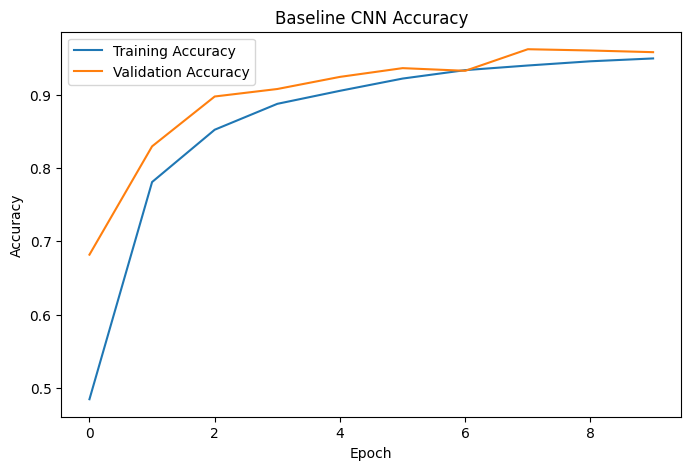

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(history_baseline.history['accuracy'], label='Training Accuracy')

plt.plot(history_baseline.history['val_accuracy'], label='Validation Accuracy')

plt.title("Baseline CNN Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.legend()

plt.show()

**14.Plot Baseline CNN Loss**

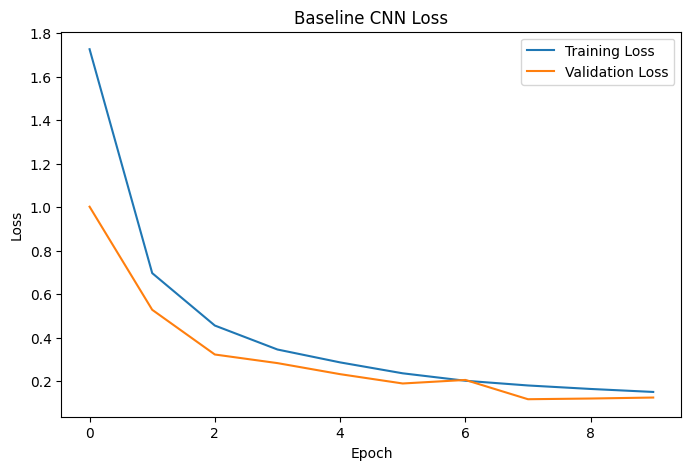

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(history_baseline.history['loss'], label='Training Loss')

plt.plot(history_baseline.history['val_loss'], label='Validation Loss')

plt.title("Baseline CNN Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.legend()

plt.show()

**PART B —DEEP CNN**

**15. Build Deep CNN Model**

In [ ]:
deep_model = models.Sequential([

    layers.Rescaling(1./255, input_shape=(150,150,3)),

    layers.Conv2D(32, (3,3), activation='relu'),
    layers.Conv2D(32, (3,3), activation='relu'),
    layers.MaxPooling2D(),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.MaxPooling2D(),

    layers.Conv2D(256, (3,3), activation='relu'),

    layers.GlobalAveragePooling2D(),

    layers.Dense(256, activation='relu'),

    layers.Dropout(0.4),

    layers.Dense(num_classes, activation='softmax')

])

deep_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_1 (Rescaling)         │ (None, 150, 150, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 146, 146, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 73, 73, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 71, 71, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 35, 35, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 33, 33, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 14, 14, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 38)             │         9,766 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 473,222 (1.81 MB)

 Trainable params: 473,222 (1.81 MB)

 Non-trainable params: 0 (0.00 B)

**16. Compile Deep CNN**

In [ ]:
deep_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

**17. Train Deep CNN**

In [ ]:
start_time = time.time()

history_deep = deep_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    callbacks=[early_stop]
)

deep_training_time = time.time() - start_time

print("Deep CNN Training Time:", deep_training_time)

Epoch 1/10


2026-05-09 16:44:46.199547: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-09 16:44:46.338195: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


8310/8439 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.2032 - loss: 2.8227

2026-05-09 16:46:12.675320: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-09 16:46:12.813030: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


8439/8439 ━━━━━━━━━━━━━━━━━━━━ 113s 12ms/step - accuracy: 0.2062 - loss: 2.8111 - val_accuracy: 0.7175 - val_loss: 0.8897
Epoch 2/10
8439/8439 ━━━━━━━━━━━━━━━━━━━━ 100s 12ms/step - accuracy: 0.7307 - loss: 0.8494 - val_accuracy: 0.8705 - val_loss: 0.4169
Epoch 3/10
8439/8439 ━━━━━━━━━━━━━━━━━━━━ 101s 12ms/step - accuracy: 0.8342 - loss: 0.5141 - val_accuracy: 0.9289 - val_loss: 0.2238
Epoch 4/10
8439/8439 ━━━━━━━━━━━━━━━━━━━━ 102s 12ms/step - accuracy: 0.8782 - loss: 0.3807 - val_accuracy: 0.9215 - val_loss: 0.2288
Epoch 5/10
8439/8439 ━━━━━━━━━━━━━━━━━━━━ 102s 12ms/step - accuracy: 0.9001 - loss: 0.3022 - val_accuracy: 0.9458 - val_loss: 0.1719
Epoch 6/10
8439/8439 ━━━━━━━━━━━━━━━━━━━━ 101s 12ms/step - accuracy: 0.9203 - loss: 0.2513 - val_accuracy: 0.9603 - val_loss: 0.1186
Epoch 7/10
8439/8439 ━━━━━━━━━━━━━━━━━━━━ 102s 12ms/step - accuracy: 0.9332 - loss: 0.2108 - val_accuracy: 0.9677 - val_loss: 0.0977
Epoch 8/10
8439/8439 ━━━━━━━━━━━━━━━━━━━━ 102s 12ms/step - accuracy: 0.9375 - lo

**18. Plot Deep CNN Accuracy**

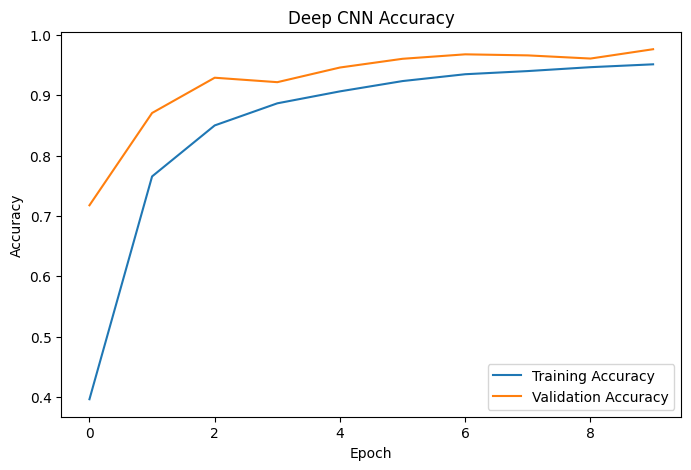

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(history_deep.history['accuracy'], label='Training Accuracy')

plt.plot(history_deep.history['val_accuracy'], label='Validation Accuracy')

plt.title("Deep CNN Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.legend()

plt.show()

**19.Plot Deep CNN Loss**

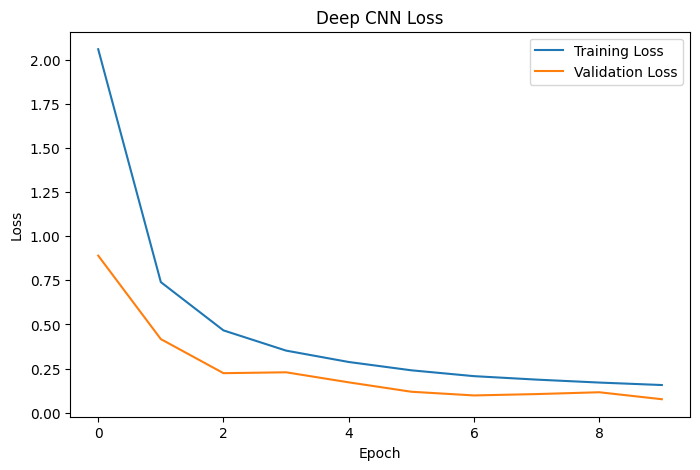

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(history_deep.history['loss'], label='Training Loss')

plt.plot(history_deep.history['val_loss'], label='Validation Loss')

plt.title("Deep CNN Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.legend()

plt.show()

**PART C — TRANSFER LEARNING USING VGG16**

**20. Load Pretrained VGG16 Model**

In [ ]:
base_model = tf.keras.applications.VGG16(
    include_top=False,
    weights='imagenet',
    input_shape=(128,128,3)
)

base_model.trainable = False

**21. Build VGG16 Model**

In [ ]:
vgg_model = models.Sequential([

    layers.Rescaling(1./255, input_shape=(128,128,3)),

    base_model,

    layers.Flatten(),

    layers.Dense(256, activation='relu'),

    layers.Dropout(0.5),

    layers.Dense(num_classes, activation='softmax')

])

vgg_model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_2 (Rescaling)         │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ vgg16 (Functional)              │ (None, 4, 4, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │     2,097,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 38)             │         9,766 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 16,821,862 (64.17 MB)

 Trainable params: 2,107,174 (8.04 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

**22. Compile VGG16 Model**

In [ ]:
vgg_model.compile(

    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),

    loss='sparse_categorical_crossentropy',

    metrics=['accuracy']

)

**23. Train model**

In [ ]:
start_time = time.time()

history_vgg = vgg_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    callbacks=[early_stop]
)

vgg_training_time = time.time() - start_time

print("VGG16 Training Time:", vgg_training_time)

Epoch 1/10
8439/8439 ━━━━━━━━━━━━━━━━━━━━ 237s 27ms/step - accuracy: 0.5583 - loss: 1.5861 - val_accuracy: 0.8981 - val_loss: 0.3606
Epoch 2/10
8439/8439 ━━━━━━━━━━━━━━━━━━━━ 225s 26ms/step - accuracy: 0.8321 - loss: 0.5259 - val_accuracy: 0.9257 - val_loss: 0.2505
Epoch 3/10
8439/8439 ━━━━━━━━━━━━━━━━━━━━ 226s 26ms/step - accuracy: 0.8721 - loss: 0.3920 - val_accuracy: 0.9381 - val_loss: 0.2013
Epoch 4/10
8439/8439 ━━━━━━━━━━━━━━━━━━━━ 226s 27ms/step - accuracy: 0.8925 - loss: 0.3262 - val_accuracy: 0.9518 - val_loss: 0.1589
Epoch 5/10
8439/8439 ━━━━━━━━━━━━━━━━━━━━ 226s 26ms/step - accuracy: 0.9064 - loss: 0.2785 - val_accuracy: 0.9541 - val_loss: 0.1438
Epoch 6/10
8439/8439 ━━━━━━━━━━━━━━━━━━━━ 225s 26ms/step - accuracy: 0.9164 - loss: 0.2483 - val_accuracy: 0.9645 - val_loss: 0.1171
Epoch 7/10
8439/8439 ━━━━━━━━━━━━━━━━━━━━ 226s 26ms/step - accuracy: 0.9241 - loss: 0.2232 - val_accuracy: 0.9702 - val_loss: 0.0975
Epoch 8/10
8439/8439 ━━━━━━━━━━━━━━━━━━━━ 226s 26ms/step - accuracy: 

**24. Plot VGG16 Accuracy**

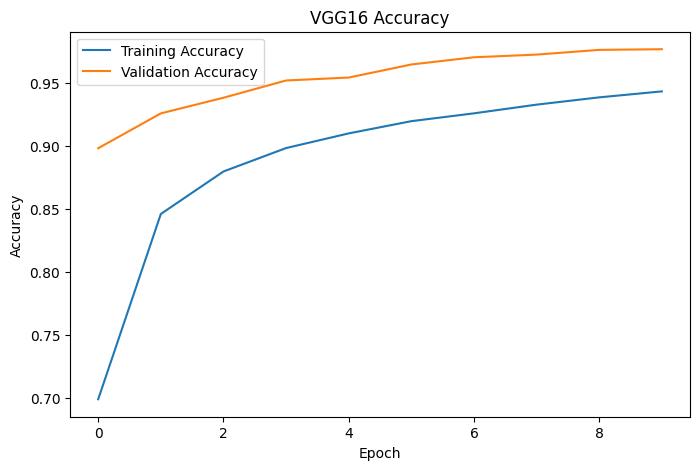

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(history_vgg.history['accuracy'], label='Training Accuracy')
plt.plot(history_vgg.history['val_accuracy'], label='Validation Accuracy')

plt.title("VGG16 Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.show()

**25. Plot VGG16 Loss**

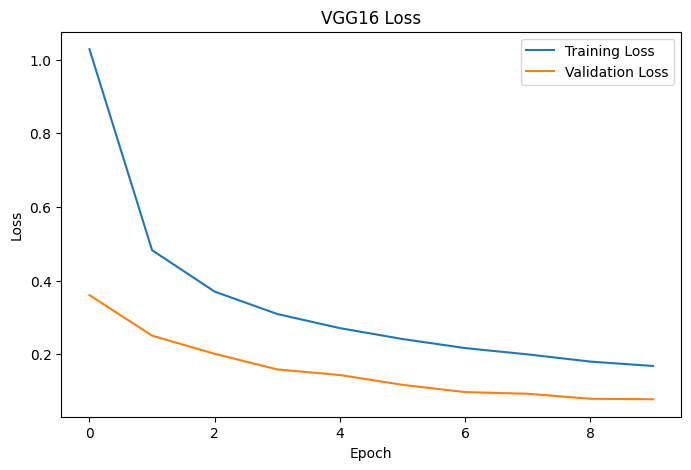

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(history_vgg.history['loss'], label='Training Loss')

plt.plot(history_vgg.history['val_loss'], label='Validation Loss')

plt.title("VGG16 Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.legend()

plt.show()

**26. Model Evaluation Function**

In [ ]:
def evaluate_model(model, model_name):

    print("\n")
    print("="*50)
    print(model_name)
    print("="*50)

    y_true = np.concatenate(
        [y.numpy() for x, y in test_ds],
        axis=0
    )

    predictions = model.predict(test_ds)

    y_pred = np.argmax(predictions, axis=1)

    print(
        classification_report(
            y_true,
            y_pred,
            target_names=class_names
        )
    )

    return y_true, y_pred

**27. Evaluate Baseline CNN**

In [ ]:
baseline_true, baseline_pred = evaluate_model(
    baseline_model,
    "BASELINE CNN"
)



BASELINE CNN
2152/2152 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step
                                                    precision    recall  f1-score   support

                                Apple___Apple_scab       0.94      0.95      0.95       504
                                 Apple___Black_rot       0.98      0.98      0.98       497
                          Apple___Cedar_apple_rust       0.82      0.99      0.90        84
                                   Apple___healthy       0.97      0.98      0.97       502
                               Blueberry___healthy       0.98      0.95      0.96       454
          Cherry_(including_sour)___Powdery_mildew       0.94      0.98      0.96       421
                 Cherry_(including_sour)___healthy       0.96      0.99      0.98       456
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot       0.96      0.81      0.88       410
                       Corn_(maize)___Common_rust_       0.99      0.99      0.99       477
               Corn_(

**28. Evaluate Deep CNN**

In [ ]:
deep_true, deep_pred = evaluate_model(
    deep_model,
    "DEEP CNN"
)



DEEP CNN
2152/2152 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step
                                                    precision    recall  f1-score   support

                                Apple___Apple_scab       0.97      0.94      0.95       504
                                 Apple___Black_rot       0.98      0.99      0.99       497
                          Apple___Cedar_apple_rust       0.87      0.99      0.93        84
                                   Apple___healthy       0.97      0.95      0.96       502
                               Blueberry___healthy       0.98      0.97      0.98       454
          Cherry_(including_sour)___Powdery_mildew       1.00      0.97      0.98       421
                 Cherry_(including_sour)___healthy       0.99      0.98      0.98       456
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot       0.97      0.89      0.93       410
                       Corn_(maize)___Common_rust_       1.00      0.99      1.00       477
               Corn_(maiz

**29. Evaluate VGG16 Model**

In [ ]:
vgg_true, vgg_pred = evaluate_model(
    vgg_model,
    "VGG16 MODEL"
)



VGG16 MODEL
2152/2152 ━━━━━━━━━━━━━━━━━━━━ 40s 18ms/step
                                                    precision    recall  f1-score   support

                                Apple___Apple_scab       0.97      0.95      0.96       504
                                 Apple___Black_rot       0.98      0.98      0.98       497
                          Apple___Cedar_apple_rust       0.83      0.99      0.90        84
                                   Apple___healthy       0.95      0.98      0.96       502
                               Blueberry___healthy       0.98      0.94      0.96       454
          Cherry_(including_sour)___Powdery_mildew       0.99      0.98      0.98       421
                 Cherry_(including_sour)___healthy       0.99      0.98      0.99       456
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot       0.96      0.85      0.90       410
                       Corn_(maize)___Common_rust_       0.98      1.00      0.99       477
               Corn_

**30. Confusion Matrix for VGG16**

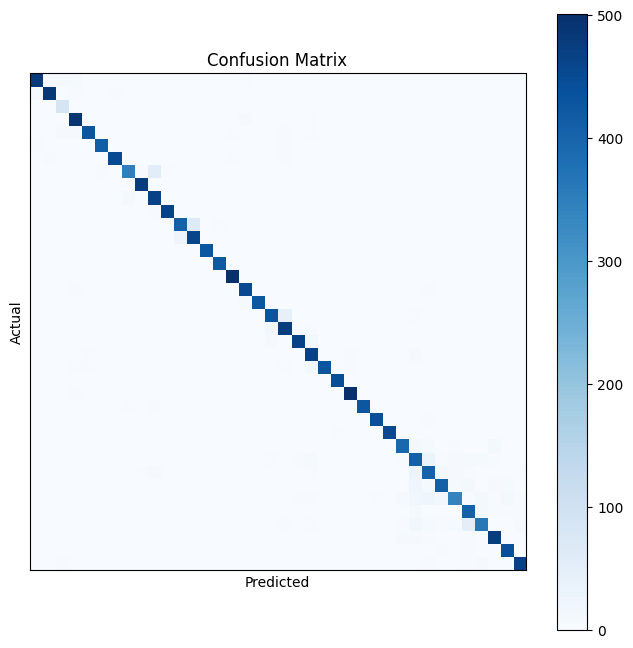

In [ ]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

cm = confusion_matrix(vgg_true, vgg_pred)

plt.figure(figsize=(8,8))

plt.imshow(cm, cmap='Blues')

plt.title("Confusion Matrix")

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.xticks([])
plt.yticks([])

plt.colorbar()

plt.show()

**31. Visualize Predictions**

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 757ms/step


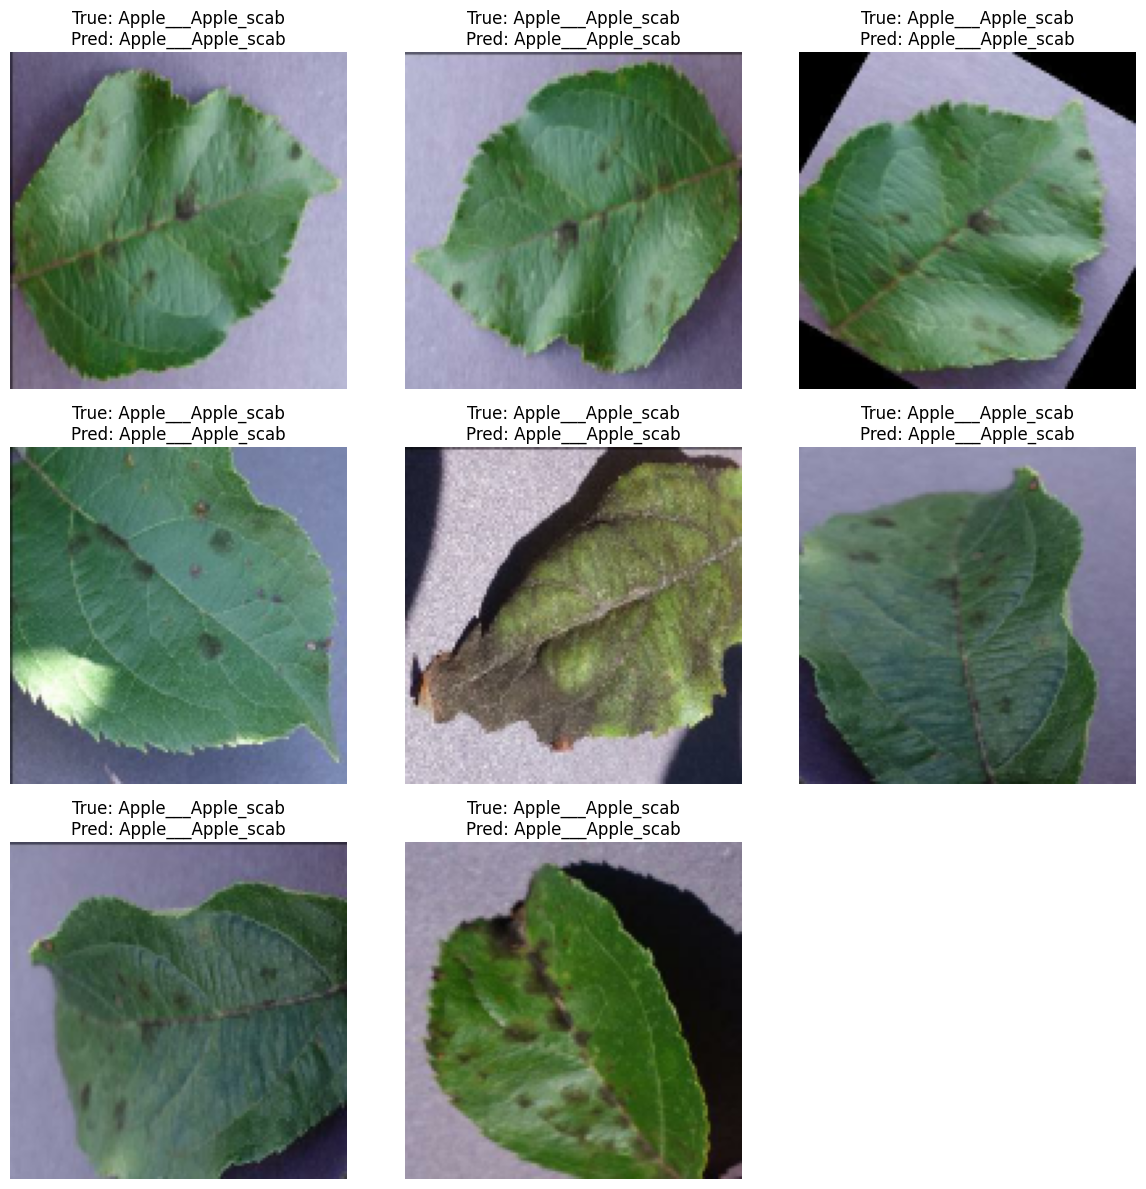

In [ ]:
plt.figure(figsize=(12,12))

for images, labels in test_ds.take(1):

    predictions = vgg_model.predict(images)

    predicted_classes = np.argmax(predictions, axis=1)

    for i in range(min(9, len(images))):

        ax = plt.subplot(3,3,i+1)

        plt.imshow(images[i].numpy().astype("uint8"))

        true_label = class_names[labels[i]]
        predicted_label = class_names[predicted_classes[i]]

        plt.title(f"True: {true_label}\nPred: {predicted_label}")

        plt.axis("off")

plt.tight_layout()
plt.show()

**32. Final Comparison Table**

In [ ]:
results = pd.DataFrame({

    "Model": [
        "Baseline CNN",
        "Deep CNN",
        "VGG16"
    ],

    "Best Validation Accuracy": [

        max(history_baseline.history['val_accuracy']),

        max(history_deep.history['val_accuracy']),

        max(history_vgg.history['val_accuracy'])
    ],

    "Training Time (seconds)": [

        round(baseline_training_time, 2),

        round(deep_training_time, 2),

        round(vgg_training_time, 2)
    ]

})

results

,Model,Best Validation Accuracy,Training Time (seconds)
0,Baseline CNN,0.961836,697.26
1,Deep CNN,0.976147,1028.66
2,VGG16,0.976620,2265.62
